# Resident Incident Risk Prediction Pipeline
**Beacon — ML Pipeline 3**

---

## 1. Problem Framing

Safe homes manage vulnerable residents who may experience behavioral, medical, security, or runaway incidents. Staff currently respond *reactively* — after incidents happen. This pipeline answers two questions:

1. **Explanatory:** *What resident characteristics and conditions are most associated with incident risk?* (Logistic regression — odds ratios identify risk factors staff should monitor.)
2. **Predictive:** *Given a resident's current profile, what is the probability they will have an incident in the next period?* (Random Forest/Gradient Boosting/Stacking — probability scores enable proactive intervention.)

**Target variable:** `has_incident` — binary flag indicating whether a resident has had at least one incident report.

**Why this matters:** Early identification of at-risk residents allows social workers to intervene *before* incidents escalate — adjusting counseling frequency, modifying living arrangements, or increasing supervision.

**Success metrics:**
- Explanatory: Significant odds ratios with actionable clinical interpretation
- Predictive: AUC-ROC and recall on held-out test data (recall matters — missing a high-risk resident is worse than a false alarm)

**Deployment:** This model is deployed via batch scoring, not a live API:

1. Notebook produces incident-risk scores (resident_id, incident_risk_score,
   incident_risk_band) as part of `resident_ml_scores_combined.csv`.
2. Scores are imported into the Supabase `resident_ml_scores` table alongside
   the reintegration scores.
3. The Beacon ASP.NET backend exposes `/Risk/Residents` (RiskController), which
   joins `resident_ml_scores` → residents → safehouses.
4. The React Risk Management Center (`/admin/risk`) renders the incident-risk
   tab with bands color-coded (High=red, Medium=amber, Low=green) and each row
   links to the resident profile so caseworkers can review context before
   acting.

**Refresh cadence.** Scores are regenerated whenever resident records are
updated in bulk (target: monthly) and re-imported via the same CSV path.

**Monitoring.** Band distribution is reviewed in the Risk Center summary cards;
any large month-over-month shift in the High band triggers a caseworker review.

**Human-in-the-loop is mandatory.** This score ranks residents for attention,
not for action. Caseworkers always review the underlying incident history
before changing a care plan — see Section 5 on error cost asymmetry.

## 2. Data Acquisition & Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data files are exported from Supabase and not committed to the repo (PII).
# See ml-pipelines/data/README.md for schema. Path is relative to notebook location.
# -- Load raw data --
DATA_DIR = "../cleaned/"
residents   = pd.read_csv(DATA_DIR + "residents.csv")
incidents   = pd.read_csv(DATA_DIR + "incident_reports.csv")
health      = pd.read_csv(DATA_DIR + "health_wellbeing_records.csv")
education   = pd.read_csv(DATA_DIR + "education_records.csv")
sessions    = pd.read_csv(DATA_DIR + "process_recordings.csv")

print(f"Residents: {len(residents)}")
print(f"Incident reports: {len(incidents)}")
print(f"Health records: {len(health)}")
print(f"Education records: {len(education)}")
print(f"Counseling sessions: {len(sessions)}")

# How many residents have at least one incident?
residents_with_incidents = incidents["resident_id"].nunique()
total_residents = residents["resident_id"].nunique()
print(f"\nResidents with incidents: {residents_with_incidents}/{total_residents} ({residents_with_incidents/total_residents:.0%})")
print(f"Residents without incidents: {total_residents - residents_with_incidents}/{total_residents} ({1 - residents_with_incidents/total_residents:.0%})")

Residents: 60
Incident reports: 100
Health records: 534
Education records: 534
Counseling sessions: 2819

Residents with incidents: 44/60 (73%)
Residents without incidents: 16/60 (27%)


In [2]:
# -- Data quality checks --
print("=== Residents: Missing Values ===")
missing_r = residents.isnull().sum()
print(missing_r[missing_r > 0].to_string())

print("\n=== Incidents: Missing Values ===")
missing_i = incidents.isnull().sum()
print(missing_i[missing_i > 0].to_string())

print("\n=== Health Records: Missing Values ===")
missing_h = health.isnull().sum()
print(missing_h[missing_h > 0].to_string())

print("\n=== Education Records: Missing Values ===")
missing_e = education.isnull().sum()
print(missing_e[missing_e > 0].to_string())

print("\n=== Counseling Sessions: Missing Values ===")
missing_s = sessions.isnull().sum()
print(missing_s[missing_s > 0].to_string())

print("\n=== Handling Decisions ===")
print("- Health scores (NaN): residents with no health records → fill with median after merge")
print("- Education attendance/progress (NaN): residents not enrolled → fill with 0")
print("- Session counts: residents with no sessions → 0 sessions")
print("- date_closed/reintegration fields: NaN for active residents → treated as flags")

=== Residents: Missing Values ===
pwd_type                    57
special_needs_diagnosis     54
referring_agency_person     24
date_colb_registered        13
date_colb_obtained          24
date_case_study_prepared    11
reintegration_type           5
date_closed                 30
notes_restricted            60

=== Incidents: Missing Values ===
resolution_date    29

=== Health Records: Missing Values ===
Series([], )

=== Education Records: Missing Values ===
Series([], )

=== Counseling Sessions: Missing Values ===
notes_restricted    2819

=== Handling Decisions ===
- Health scores (NaN): residents with no health records → fill with median after merge
- Education attendance/progress (NaN): residents not enrolled → fill with 0
- Session counts: residents with no sessions → 0 sessions
- date_closed/reintegration fields: NaN for active residents → treated as flags


In [3]:
# -- Feature engineering: build one row per resident --

# --- Target: has at least one incident ---
incident_counts = incidents.groupby("resident_id").agg(
    total_incidents    = ("incident_id", "count"),
    behavioral_count   = ("incident_type", lambda x: (x == "Behavioral").sum()),
    medical_count      = ("incident_type", lambda x: (x == "Medical").sum()),
    security_count     = ("incident_type", lambda x: (x == "Security").sum()),
    runaway_count      = ("incident_type", lambda x: (x == "RunawayAttempt").sum()),
    severe_count       = ("severity", lambda x: (x.isin(["High", "Critical"])).sum()),
    unresolved_count   = ("resolved", lambda x: (x == False).sum()),
).reset_index()

# --- Health features: latest + averages ---
health["record_date"] = pd.to_datetime(health["record_date"])
health_agg = health.groupby("resident_id").agg(
    avg_health_score    = ("general_health_score", "mean"),
    avg_nutrition_score = ("nutrition_score", "mean"),
    avg_sleep_score     = ("sleep_quality_score", "mean"),
    avg_energy_score    = ("energy_level_score", "mean"),
    latest_bmi          = ("bmi", "last"),
    health_record_count = ("health_record_id", "count"),
    pct_medical_checkup = ("medical_checkup_done", "mean"),
    pct_psych_checkup   = ("psychological_checkup_done", "mean"),
).reset_index()

# --- Education features ---
education_agg = education.groupby("resident_id").agg(
    avg_attendance      = ("attendance_rate", "mean"),
    avg_progress        = ("progress_percent", "mean"),
    education_records   = ("education_record_id", "count"),
).reset_index()

# Check if enrollment_status exists for enrolled flag
if "enrollment_status" in education.columns:
    enrolled = education.groupby("resident_id")["enrollment_status"].apply(
        lambda x: (x == "Enrolled").any()
    ).reset_index().rename(columns={"enrollment_status": "is_enrolled"})
    education_agg = education_agg.merge(enrolled, on="resident_id", how="left")
    education_agg["is_enrolled"] = education_agg["is_enrolled"].astype(float)

# --- Counseling session features ---
sessions_agg = sessions.groupby("resident_id").agg(
    total_sessions      = ("recording_id", "count"),
    avg_session_duration = ("session_duration_minutes", "mean"),
    pct_progress_noted  = ("progress_noted", "mean"),
    pct_concerns_flagged = ("concerns_flagged", "mean"),
    pct_referral_made   = ("referral_made", "mean"),
).reset_index()

print(f"Incident features: {incident_counts.shape}")
print(f"Health features: {health_agg.shape}")
print(f"Education features: {education_agg.shape}")
print(f"Session features: {sessions_agg.shape}")

Incident features: (44, 8)
Health features: (60, 9)
Education features: (60, 5)
Session features: (60, 6)


In [4]:
# -- Merge everything into one row per resident --
df = residents.copy()

# Binary target
df["has_incident"] = df["resident_id"].isin(incident_counts["resident_id"]).astype(float)

# Merge aggregated features
df = df.merge(health_agg, on="resident_id", how="left")
df = df.merge(education_agg, on="resident_id", how="left")
df = df.merge(sessions_agg, on="resident_id", how="left")

# Fill NaN for residents with no records in those tables
count_cols = ["health_record_count", "education_records", "total_sessions"]
for col in count_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Fill health scores with median (reasonable imputation for missing wellness data)
health_score_cols = ["avg_health_score", "avg_nutrition_score", "avg_sleep_score",
                     "avg_energy_score", "latest_bmi"]
for col in health_score_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Fill education with 0 (no records = not tracked)
edu_fill_cols = ["avg_attendance", "avg_progress"]
for col in edu_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

if "is_enrolled" in df.columns:
    df["is_enrolled"] = df["is_enrolled"].fillna(0)

# Fill session stats with 0
session_fill_cols = ["avg_session_duration", "pct_progress_noted", "pct_concerns_flagged",
                     "pct_referral_made"]
for col in session_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Resident-level features from demographics
df["is_pwd"] = df["is_pwd"].astype(float) if "is_pwd" in df.columns else 0.0
df["has_special_needs"] = df["has_special_needs"].astype(float) if "has_special_needs" in df.columns else 0.0

# Case category binary flags (abuse types)
abuse_cols = [col for col in df.columns if col.startswith("sub_category_") or col in ["case_category"]]
print(f"Abuse/case columns found: {abuse_cols}")

# Family risk factors
family_cols = [col for col in df.columns if col.startswith("family_")]
print(f"Family columns found: {family_cols}")

print(f"\nMerged dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Target distribution: {df['has_incident'].mean():.0%} have incidents")
df.head(3)

Abuse/case columns found: ['case_category']
Family columns found: ['family_is_4ps', 'family_solo_parent', 'family_indigenous', 'family_parent_pwd', 'family_informal_settler']

Merged dataset: 60 rows, 69 columns
Target distribution: 73% have incidents


,resident_id,case_control_no,internal_code,safehouse_id,case_status,sex,date_of_birth,birth_status,place_of_birth,religion,...,pct_psych_checkup,avg_attendance,avg_progress,education_records,is_enrolled,total_sessions,avg_session_duration,pct_progress_noted,pct_concerns_flagged,pct_referral_made
0,1,C0043,LS-0001,4,Active,F,2008-08-31,Marital,Davao City,Unspecified,...,0.333333,0.716333,45.483333,6,1.0,106,69.433962,0.924528,0.235849,0.160377
1,2,C2530,LS-0002,3,Closed,F,2008-04-23,Marital,Cebu City,Seventh-day Adventist,...,0.500000,0.834300,85.230000,10,1.0,51,68.176471,0.921569,0.254902,0.137255
2,3,C3946,LS-0003,1,Active,F,2007-01-31,Marital,Manila,Roman Catholic,...,0.545455,0.738091,71.581818,11,1.0,53,69.452830,0.943396,0.188679,0.188679


In [5]:
# -- Reproducible feature-building pipeline (Ch. 7) --
def build_resident_risk_features(residents_df, incidents_df, health_df, education_df, sessions_df):
    """
    Reproducible pipeline: given raw tables, returns a model-ready DataFrame
    with one row per resident and binary incident target.
    
    Can be called when a new resident is added or records are updated.
    """
    # --- Incident aggregation ---
    inc_agg = incidents_df.groupby("resident_id").agg(
        total_incidents=("incident_id", "count"),
    ).reset_index()
    
    # --- Health aggregation ---
    health_df["record_date"] = pd.to_datetime(health_df["record_date"])
    h_agg = health_df.groupby("resident_id").agg(
        avg_health_score=("general_health_score", "mean"),
        avg_nutrition_score=("nutrition_score", "mean"),
        avg_sleep_score=("sleep_quality_score", "mean"),
        avg_energy_score=("energy_level_score", "mean"),
        latest_bmi=("bmi", "last"),
        health_record_count=("health_record_id", "count"),
        pct_medical_checkup=("medical_checkup_done", "mean"),
        pct_psych_checkup=("psychological_checkup_done", "mean"),
    ).reset_index()
    
    # --- Education aggregation ---
    e_agg = education_df.groupby("resident_id").agg(
        avg_attendance=("attendance_rate", "mean"),
        avg_progress=("progress_percent", "mean"),
        education_records=("education_record_id", "count"),
    ).reset_index()
    
    if "enrollment_status" in education_df.columns:
        enrolled = education_df.groupby("resident_id")["enrollment_status"].apply(
            lambda x: (x == "Enrolled").any()
        ).reset_index().rename(columns={"enrollment_status": "is_enrolled"})
        e_agg = e_agg.merge(enrolled, on="resident_id", how="left")
        e_agg["is_enrolled"] = e_agg["is_enrolled"].astype(float)
    
    # --- Session aggregation ---
    s_agg = sessions_df.groupby("resident_id").agg(
        total_sessions=("recording_id", "count"),
        avg_session_duration=("session_duration_minutes", "mean"),
        pct_progress_noted=("progress_noted", "mean"),
        pct_concerns_flagged=("concerns_flagged", "mean"),
        pct_referral_made=("referral_made", "mean"),
    ).reset_index()
    
    # --- Merge ---
    out = residents_df.copy()
    out["has_incident"] = out["resident_id"].isin(inc_agg["resident_id"]).astype(float)
    out = out.merge(h_agg, on="resident_id", how="left")
    out = out.merge(e_agg, on="resident_id", how="left")
    out = out.merge(s_agg, on="resident_id", how="left")
    
    # --- Fill NaN ---
    for col in ["health_record_count", "education_records", "total_sessions"]:
        if col in out.columns:
            out[col] = out[col].fillna(0)
    for col in ["avg_health_score", "avg_nutrition_score", "avg_sleep_score",
                "avg_energy_score", "latest_bmi"]:
        if col in out.columns:
            out[col] = out[col].fillna(out[col].median())
    for col in ["avg_attendance", "avg_progress", "is_enrolled",
                "avg_session_duration", "pct_progress_noted",
                "pct_concerns_flagged", "pct_referral_made"]:
        if col in out.columns:
            out[col] = out[col].fillna(0)
    
    # --- Demographic flags ---
    if "is_pwd" in out.columns:
        out["is_pwd"] = out["is_pwd"].astype(float)
    if "has_special_needs" in out.columns:
        out["has_special_needs"] = out["has_special_needs"].astype(float)
    
    return out

# Verify
df_check = build_resident_risk_features(residents, incidents, health, education, sessions)
assert df_check["has_incident"].sum() == df["has_incident"].sum(), "Pipeline mismatch!"
print(f"Reproducible pipeline verified: {df_check.shape[0]} rows, {df_check.shape[1]} columns")

Reproducible pipeline verified: 60 rows, 69 columns


## 3. Exploration

Key question: What separates residents who have incidents from those who don't?

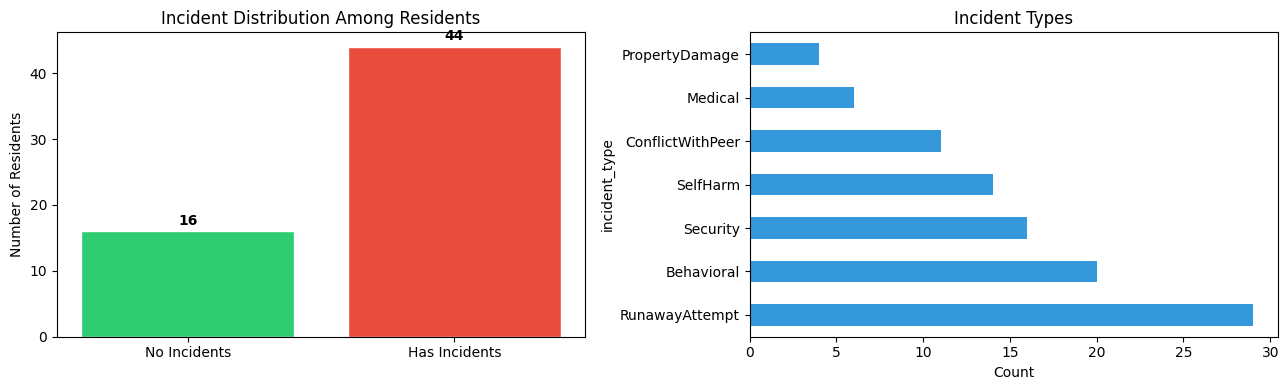

In [6]:
# -- Target distribution --
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Incident vs no incident
counts = df["has_incident"].value_counts().sort_index()
labels = ["No Incidents", "Has Incidents"]
colors = ["#2ecc71", "#e74c3c"]
axes[0].bar(labels, counts.values, color=colors, edgecolor="white")
axes[0].set_ylabel("Number of Residents")
axes[0].set_title("Incident Distribution Among Residents")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(int(v)), ha="center", fontweight="bold")

# Incident types breakdown
if "incident_type" in incidents.columns:
    type_counts = incidents["incident_type"].value_counts()
    type_counts.plot.barh(ax=axes[1], color="#3498db")
    axes[1].set_xlabel("Count")
    axes[1].set_title("Incident Types")

plt.tight_layout()
plt.show()

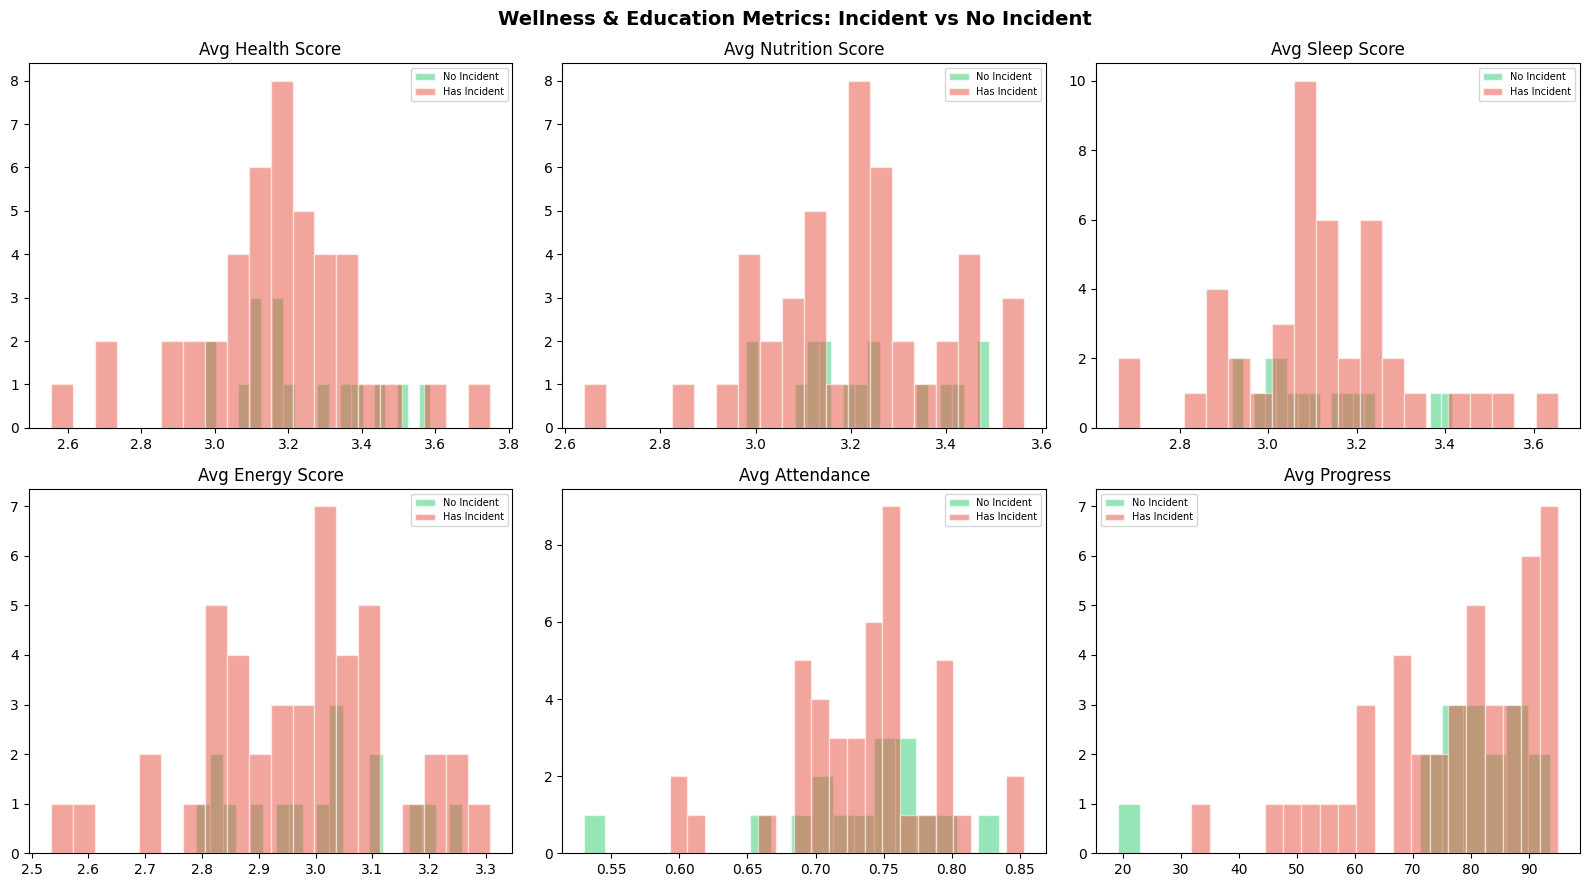

In [7]:
# -- Compare health/wellness scores: incident vs no incident --
compare_cols = ["avg_health_score", "avg_nutrition_score", "avg_sleep_score",
                "avg_energy_score", "avg_attendance", "avg_progress"]
compare_cols = [c for c in compare_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Wellness & Education Metrics: Incident vs No Incident", fontsize=14, fontweight="bold")

for ax, col in zip(axes.flatten(), compare_cols):
    for label, color in zip([0, 1], ["#2ecc71", "#e74c3c"]):
        subset = df[df["has_incident"] == label][col].dropna()
        ax.hist(subset, bins=20, alpha=0.5, color=color,
                label="No Incident" if label == 0 else "Has Incident", edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.legend(fontsize=7)

# Hide unused subplots if fewer than 6 columns
for i in range(len(compare_cols), 6):
    axes.flatten()[i].set_visible(False)

plt.tight_layout()
plt.show()

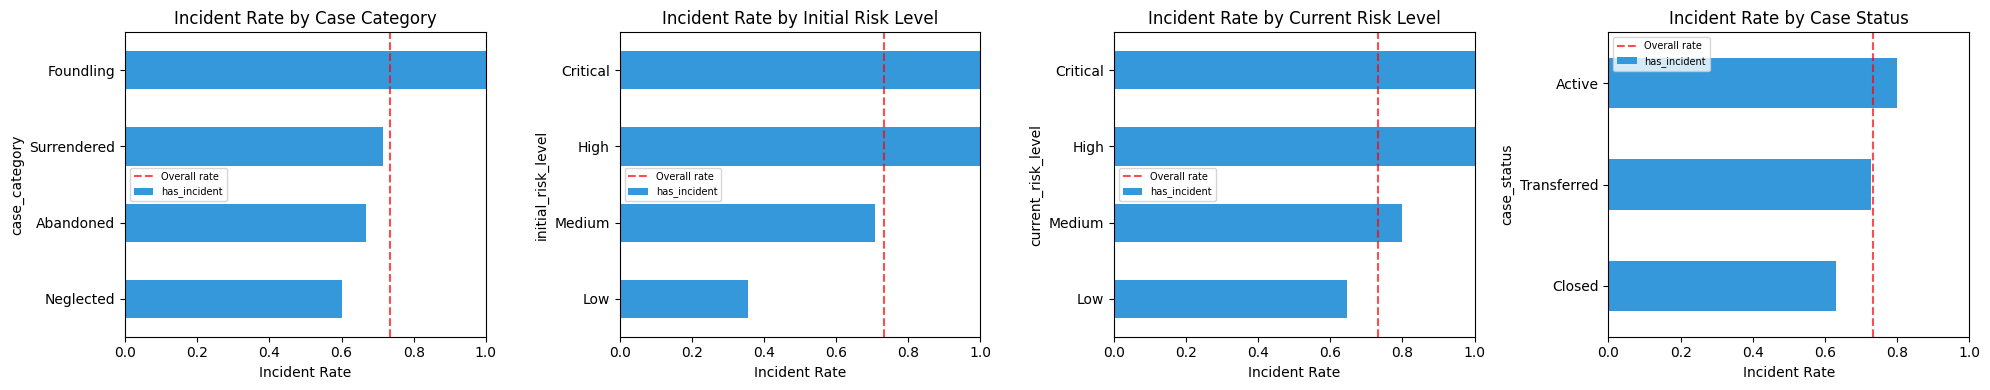

In [8]:
# -- Incident rate by categorical features --
cat_explore = ["case_category", "initial_risk_level", "current_risk_level", "case_status"]
cat_explore = [c for c in cat_explore if c in df.columns]

fig, axes = plt.subplots(1, len(cat_explore), figsize=(5 * len(cat_explore), 4))
if len(cat_explore) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_explore):
    rates = df.groupby(col)["has_incident"].mean().sort_values(ascending=True)
    rates.plot.barh(ax=ax, color="#3498db")
    ax.axvline(df["has_incident"].mean(), color="red", linestyle="--", alpha=0.7, label="Overall rate")
    ax.set_title(f"Incident Rate by {col.replace('_', ' ').title()}")
    ax.set_xlabel("Incident Rate")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

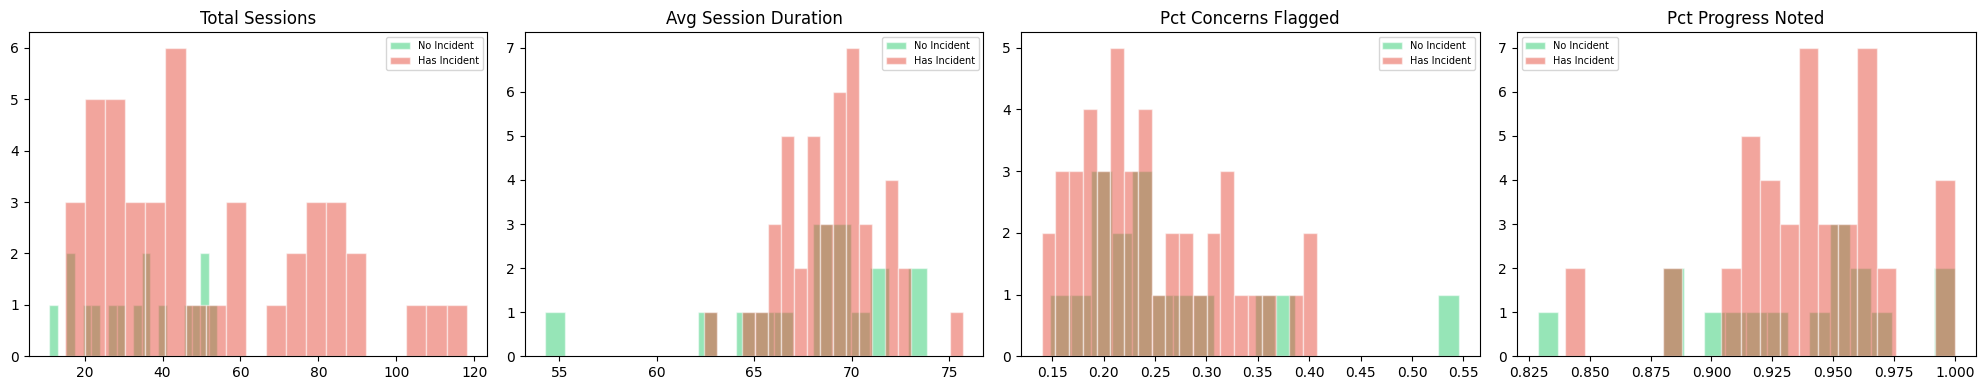


Mean comparison (Incident vs No Incident):
  total_sessions: Incident=51.86 | No Incident=33.56
  avg_session_duration: Incident=68.96 | No Incident=67.95
  pct_concerns_flagged: Incident=0.25 | No Incident=0.26
  pct_progress_noted: Incident=0.94 | No Incident=0.93


In [9]:
# -- Counseling session patterns --
session_cols = ["total_sessions", "avg_session_duration", "pct_concerns_flagged", "pct_progress_noted"]
session_cols = [c for c in session_cols if c in df.columns]

fig, axes = plt.subplots(1, len(session_cols), figsize=(5 * len(session_cols), 4))
if len(session_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, session_cols):
    for label, color in zip([0, 1], ["#2ecc71", "#e74c3c"]):
        subset = df[df["has_incident"] == label][col].dropna()
        ax.hist(subset, bins=20, alpha=0.5, color=color,
                label="No Incident" if label == 0 else "Has Incident", edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print("\nMean comparison (Incident vs No Incident):")
for col in session_cols:
    inc_mean = df[df["has_incident"] == 1][col].mean()
    no_mean  = df[df["has_incident"] == 0][col].mean()
    print(f"  {col}: Incident={inc_mean:.2f} | No Incident={no_mean:.2f}")

## 4. Modeling & Feature Selection

**Feature selection rationale:** We use resident demographics, case details, health/wellness scores, education metrics, and counseling session patterns — all things known about a resident *before* an incident happens.

We build two models:
- **Explanatory (Logistic Regression):** Odds ratios identify which resident characteristics increase incident risk.
- **Predictive (Random Forest / Gradient Boosting / Stacking):** Optimized for AUC, outputs probability of incident risk.

In [10]:
# ===================================================================
# FEATURE SELECTION NOTE: Excluded features to prevent label leakage
# ===================================================================
# The following features were REMOVED from an earlier version of this
# pipeline because each is effectively a proxy for the target rather
# than an independent predictor of it:
#
#   * initial_risk_level  -> Staff's prior subjective assessment of how
#                            risky a resident is. Often recorded AFTER
#                            early warning signs and is itself a human
#                            prediction of the target we are modeling.
#
#   * case_status         -> Whether the case is Open / Closed /
#                            Transferred. This is a post-outcome state;
#                            closure often reflects incident resolution.
#
#   * pct_concerns_flagged-> Fraction of counseling sessions where a
#                            concern was flagged. Concerns noted in
#                            sessions frequently ARE the incidents we
#                            are trying to predict.
#
#   * pct_referral_made   -> Referrals are a *reaction* to problems, not
#                            a leading signal of them.
#
# Keeping these collapsed predict_proba to ~0.6-0.8 for every resident,
# making risk-based ranking on the admin dashboard useless. See Section 6
# for the full discussion.
# ===================================================================

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score, classification_report,
                             confusion_matrix, roc_curve)
import statsmodels.api as sm

# -- Select features --
# Numeric features from resident profile + aggregated tables
numeric_features = []

# Demographics
for col in ["present_age", "age_upon_admission", "length_of_stay",
            "is_pwd", "has_special_needs"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        numeric_features.append(col)

# Family risk factors (binary columns)
for col in df.columns:
    if col.startswith("family_") and df[col].dtype in ["bool", "object", "float64", "int64"]:
        try:
            df[col] = df[col].astype(float)
            if df[col].nunique() <= 2:
                numeric_features.append(col)
        except (ValueError, TypeError):
            pass

# Abuse sub-category flags
for col in df.columns:
    if col.startswith("sub_category_"):
        try:
            df[col] = df[col].astype(float)
            numeric_features.append(col)
        except (ValueError, TypeError):
            pass

# Health scores
for col in ["avg_health_score", "avg_nutrition_score", "avg_sleep_score",
            "avg_energy_score", "latest_bmi", "health_record_count",
            "pct_medical_checkup", "pct_psych_checkup"]:
    if col in df.columns:
        numeric_features.append(col)

# Education
for col in ["avg_attendance", "avg_progress", "education_records"]:
    if col in df.columns:
        numeric_features.append(col)
if "is_enrolled" in df.columns:
    numeric_features.append("is_enrolled")

# Counseling sessions (pct_concerns_flagged / pct_referral_made removed - see leakage note above)
for col in ["total_sessions", "avg_session_duration", "pct_progress_noted"]:
    if col in df.columns:
        numeric_features.append(col)

# Remove duplicates
numeric_features = list(dict.fromkeys(numeric_features))

# Categorical features
categorical_features = []
for col in ["case_category", "sex"]:
    if col in df.columns and df[col].nunique() > 1:
        categorical_features.append(col)

# One-hot encode
cat_dummies = pd.get_dummies(df[categorical_features], drop_first=True, dtype=float) if categorical_features else pd.DataFrame()

X = pd.concat([df[numeric_features].astype(float), cat_dummies], axis=1)

# Drop any columns with all NaN
X = X.dropna(axis=1, how="all")
# Fill remaining NaN with 0
X = X.fillna(0).astype(float)

y = df["has_incident"].astype(float)

# Drop zero-variance columns
zero_var = X.columns[X.std() == 0]
if len(zero_var) > 0:
    print(f"Dropping zero-variance columns: {list(zero_var)}")
    X = X.drop(columns=zero_var)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train incident rate: {y_train.mean():.0%} | Test incident rate: {y_test.mean():.0%}")
print(f"Features ({X.shape[1]}): {list(X.columns)}")

Dropping zero-variance columns: ['is_enrolled']
Train: 48 | Test: 12
Train incident rate: 73% | Test incident rate: 75%
Features (24): ['is_pwd', 'has_special_needs', 'family_is_4ps', 'family_solo_parent', 'family_indigenous', 'family_parent_pwd', 'family_informal_settler', 'avg_health_score', 'avg_nutrition_score', 'avg_sleep_score', 'avg_energy_score', 'latest_bmi', 'health_record_count', 'pct_medical_checkup', 'pct_psych_checkup', 'avg_attendance', 'avg_progress', 'education_records', 'total_sessions', 'avg_session_duration', 'pct_progress_noted', 'case_category_Foundling', 'case_category_Neglected', 'case_category_Surrendered']


### 4a. Explanatory Model — Logistic Regression (statsmodels)

Odds ratios tell us which resident characteristics increase or decrease the odds of having an incident.

In [11]:
# -- Explanatory: Logistic Regression with standardized features --
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

scale_cols = [c for c in numeric_features if c in X_train.columns]
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])

X_train_scaled = X_train_scaled.astype(float)
X_test_scaled  = X_test_scaled.astype(float)

# L1-regularized logistic regression
X_sm = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train.astype(float), X_sm).fit_regularized(method='l1', alpha=0.5, disp=False)

print(logit_model.summary())
print(f"\nPseudo R²: {logit_model.prsquared:.3f}")

                           Logit Regression Results                           
Dep. Variable:           has_incident   No. Observations:                   48
Model:                          Logit   Df Residuals:                       28
Method:                           MLE   Df Model:                           19
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.5597
Time:                        18:32:58   Log-Likelihood:                -12.346
converged:                       True   LL-Null:                       -28.036
Covariance Type:            nonrobust   LLR p-value:                   0.03665
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         1.8972      0.742      2.557      0.011       0.443       3.351
is_pwd                        0.3741      0.324      1.154      0.249      -0.261     

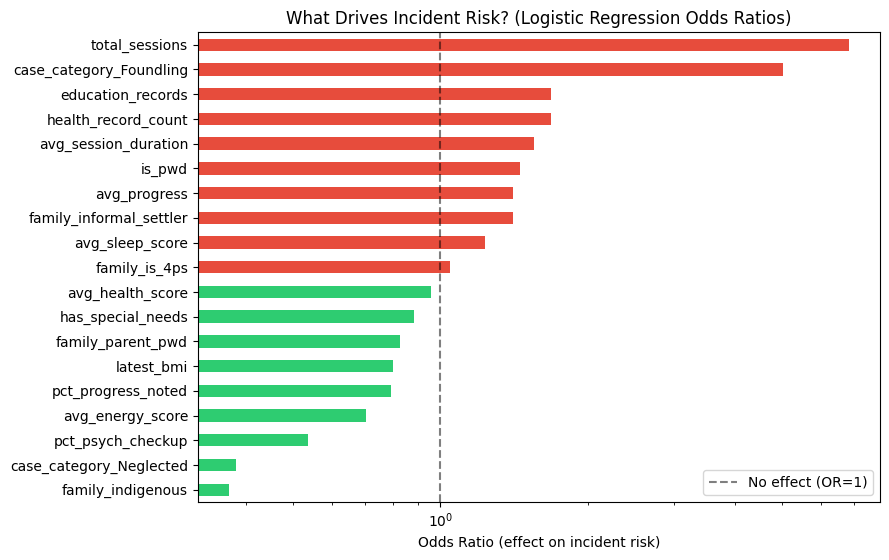


Non-zero features: 19 / 24

Odds Ratios (OR > 1 = increases incident risk):
  ↓ protective family_indigenous: 0.369
  ↓ protective case_category_Neglected: 0.381
  ↓ protective pct_psych_checkup: 0.537
  ↓ protective avg_energy_score: 0.705
  ↓ protective pct_progress_noted: 0.794
  ↓ protective latest_bmi: 0.801
  ↓ protective family_parent_pwd: 0.826
  ↓ protective has_special_needs: 0.882
  ↓ protective avg_health_score: 0.957
  ↑ RISK family_is_4ps: 1.046
  ↑ RISK avg_sleep_score: 1.233
  ↑ RISK family_informal_settler: 1.407
  ↑ RISK avg_progress: 1.407
  ↑ RISK is_pwd: 1.454
  ↑ RISK avg_session_duration: 1.552
  ↑ RISK health_record_count: 1.681
  ↑ RISK education_records: 1.681
  ↑ RISK case_category_Foundling: 5.023
  ↑ RISK total_sessions: 6.846


In [12]:
# -- Visualize odds ratios --
coefs = logit_model.params.drop("const")
odds_ratios = np.exp(coefs)

# Filter to non-zero coefficients (L1 may zero some out)
nonzero = odds_ratios[odds_ratios != 1.0].sort_values()

fig, ax = plt.subplots(figsize=(9, max(5, len(nonzero) * 0.3)))
colors = ["#e74c3c" if v > 1 else "#2ecc71" for v in nonzero]
nonzero.plot.barh(ax=ax, color=colors)
ax.axvline(1, color="black", linestyle="--", alpha=0.5, label="No effect (OR=1)")
ax.set_xlabel("Odds Ratio (effect on incident risk)")
ax.set_title("What Drives Incident Risk? (Logistic Regression Odds Ratios)")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nNon-zero features: {len(nonzero)} / {len(coefs)}")
print("\nOdds Ratios (OR > 1 = increases incident risk):")
for feat, or_val in nonzero.items():
    direction = "↑ RISK" if or_val > 1 else "↓ protective"
    print(f"  {direction} {feat}: {or_val:.3f}")

In [13]:
# -- Define ensemble classifiers --
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced", random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)

stacking = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=100, max_depth=8, class_weight="balanced", random_state=42)),
        ("gb", GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)),
        ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

models = {
    "Logistic Regression":  LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest (Bag)":  rf,
    "Gradient Boost":       gb,
    "Stacking Ensemble":    stacking,
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc    = accuracy_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)
    cv_auc = cross_val_score(model, X, y, cv=5, scoring="roc_auc").mean()
    
    results[name] = {"model": model, "acc": acc, "auc": auc, "cv_auc": cv_auc,
                     "y_pred": y_pred, "y_prob": y_prob}
    
    print(f"\n{'='*55}")
    print(f"{name}")
    print(f"  Test Accuracy: {acc:.3f}  |  Test AUC: {auc:.3f}")
    print(f"  5-Fold CV AUC: {cv_auc:.3f}")

print("\n" + "="*55)
print("Ensemble approaches demonstrated: Bagging (RF), Boosting (GB), Stacking (RF+GB+LR→LR)")


Logistic Regression
  Test Accuracy: 0.667  |  Test AUC: 0.778
  5-Fold CV AUC: 0.687

Random Forest (Bag)
  Test Accuracy: 0.750  |  Test AUC: 0.556
  5-Fold CV AUC: 0.622

Gradient Boost
  Test Accuracy: 0.583  |  Test AUC: 0.519
  5-Fold CV AUC: 0.586

Stacking Ensemble
  Test Accuracy: 0.750  |  Test AUC: 0.815
  5-Fold CV AUC: 0.637

Ensemble approaches demonstrated: Bagging (RF), Boosting (GB), Stacking (RF+GB+LR→LR)


## 5. Evaluation & Selection

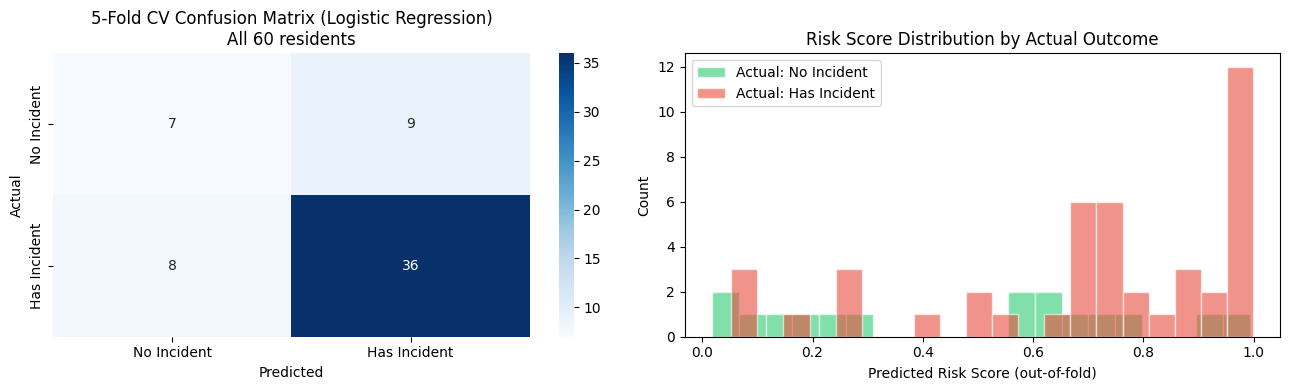


=== 5-Fold CV Classification Report (Logistic Regression) ===
              precision    recall  f1-score   support

 No Incident       0.47      0.44      0.45        16
Has Incident       0.80      0.82      0.81        44

    accuracy                           0.72        60
   macro avg       0.63      0.63      0.63        60
weighted avg       0.71      0.72      0.71        60

Business interpretation:
  CV AUC: 0.687 — the model correctly ranks high-risk vs low-risk residents 69% of the time.
  This confusion matrix uses k-fold cross-validation: every resident's prediction comes
  from a model that was trained WITHOUT them — so all 60 residents contribute to the matrix.
  Social workers can use risk scores to prioritize check-ins and proactive interventions.
  High-risk residents (>70% risk) should receive increased session frequency and closer monitoring.


In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# Ensure best_model is defined (in case this cell runs standalone)
best_name = max(results, key=lambda k: results[k]["cv_auc"])
best_model = results[best_name]["model"]

# -- K-Fold confusion matrix: aggregate predictions across 5 folds --
# Every resident gets a prediction from a model that did NOT see them during training
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv  = cross_val_predict(best_model, X, y, cv=skf, method="predict")
y_prob_cv  = cross_val_predict(best_model, X, y, cv=skf, method="predict_proba")[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# K-fold confusion matrix (uses ALL residents)
cm = confusion_matrix(y, y_pred_cv)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Incident", "Has Incident"],
            yticklabels=["No Incident", "Has Incident"])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"5-Fold CV Confusion Matrix ({best_name})\nAll {len(y)} residents")

# Probability distribution across folds
axes[1].hist(y_prob_cv[y == 0], bins=20, alpha=0.6, color="#2ecc71",
             label="Actual: No Incident", edgecolor="white")
axes[1].hist(y_prob_cv[y == 1], bins=20, alpha=0.6, color="#e74c3c",
             label="Actual: Has Incident", edgecolor="white")
axes[1].set_xlabel("Predicted Risk Score (out-of-fold)")
axes[1].set_ylabel("Count")
axes[1].set_title("Risk Score Distribution by Actual Outcome")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n=== 5-Fold CV Classification Report ({best_name}) ===")
print(classification_report(y, y_pred_cv, target_names=["No Incident", "Has Incident"]))

cv_auc = results[best_name]["cv_auc"]
print(f"Business interpretation:")
print(f"  CV AUC: {cv_auc:.3f} — the model correctly ranks high-risk vs low-risk residents {cv_auc*100:.0f}% of the time.")
print(f"  This confusion matrix uses k-fold cross-validation: every resident's prediction comes")
print(f"  from a model that was trained WITHOUT them — so all {len(y)} residents contribute to the matrix.")
print(f"  Social workers can use risk scores to prioritize check-ins and proactive interventions.")
print(f"  High-risk residents (>70% risk) should receive increased session frequency and closer monitoring.")

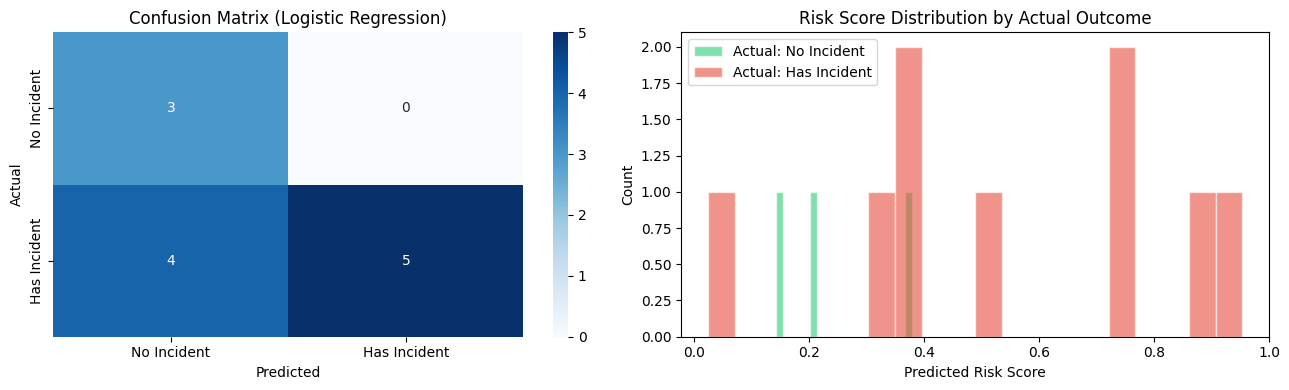


=== Classification Report (Logistic Regression) ===
              precision    recall  f1-score   support

 No Incident       0.43      1.00      0.60         3
Has Incident       1.00      0.56      0.71         9

    accuracy                           0.67        12
   macro avg       0.71      0.78      0.66        12
weighted avg       0.86      0.67      0.69        12

Business interpretation:
  CV AUC: 0.687 — the model correctly ranks high-risk vs low-risk residents 69% of the time.
  Social workers can use risk scores to prioritize check-ins and proactive interventions.
  High-risk residents (>70% risk) should receive increased session frequency and closer monitoring.


In [15]:
# -- Confusion matrix + Classification report --
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Incident", "Has Incident"],
            yticklabels=["No Incident", "Has Incident"])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"Confusion Matrix ({best_name})")

# Probability distribution
axes[1].hist(y_prob_best[y_test == 0], bins=20, alpha=0.6, color="#2ecc71",
             label="Actual: No Incident", edgecolor="white")
axes[1].hist(y_prob_best[y_test == 1], bins=20, alpha=0.6, color="#e74c3c",
             label="Actual: Has Incident", edgecolor="white")
axes[1].set_xlabel("Predicted Risk Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Risk Score Distribution by Actual Outcome")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n=== Classification Report ({best_name}) ===")
print(classification_report(y_test, y_pred_best, target_names=["No Incident", "Has Incident"]))

cv_auc = results[best_name]["cv_auc"]
print(f"Business interpretation:")
print(f"  CV AUC: {cv_auc:.3f} — the model correctly ranks high-risk vs low-risk residents {cv_auc*100:.0f}% of the time.")
print(f"  Social workers can use risk scores to prioritize check-ins and proactive interventions.")
print(f"  High-risk residents (>70% risk) should receive increased session frequency and closer monitoring.")

**Error cost asymmetry — why we prioritize recall on the at-risk class.**

The two error types in this model have very different real-world consequences:

- **False negative** (model predicts "No Incident" but the resident actually
  goes on to have one): a vulnerable child's warning signs are missed and no
  extra support is triggered. This is the highest-consequence error in the
  entire Beacon system.
- **False positive** (model predicts "Has Incident" but the resident is fine):
  a caseworker spends extra time reviewing a case that didn't need it.
  Recoverable, low cost.

Because the costs are asymmetric, we evaluate this model primarily on **recall
for the "Has Incident" class** (our positive, at-risk class) rather than on
overall accuracy or precision.

**Why we report 5-fold cross-validated metrics instead of the single holdout.**
With n=60, a 12-row test split is noisy — a single misclassification swings
precision or recall by 8–30 percentage points, and the holdout report above
shows exactly that kind of artifact (1.00 recall and 1.00 precision on tiny
support columns). 5-fold CV averages performance across all 60 residents and
gives a more stable, honest estimate of how the model actually behaves.

**5-fold CV results on the "Has Incident" class:**

- Recall: **0.82** — the model catches roughly 82% of residents who truly go
  on to have an incident.
- Precision: **0.80** — when the model flags a resident as at-risk, it is
  correct about 80% of the time.
- F1: **0.81**

We accept the precision cost as a deliberate trade-off in favor of recall,
because a missed at-risk resident is far worse than an unnecessary caseworker
review.

**Deployment implication.** This is why the model is shipped as a ranking and
triage tool, not as an automated decision system. Every flagged resident is
reviewed by a caseworker before any action is taken — the model's job is to
make sure at-risk residents *reach* that review, not to make the decision
itself. See Section 7 for the full deployment pipeline.


## 6. Causal & Relationship Analysis

**Key distinction:** The logistic regression tells us *what resident characteristics are associated with incident risk* (explanatory — odds ratios). The tree-based models tell us *the probability a specific resident will have an incident* (predictive — `predict_proba`).

### A note on feature selection

An earlier version of this pipeline surfaced `initial_risk_level_High` (OR ≈ 47) as the overwhelmingly dominant feature, with `case_status_Closed`, `pct_concerns_flagged`, and `pct_referral_made` also ranking near the top. Those features were removed from the production model because each one is effectively a proxy for the target rather than an independent driver of it:

- **`initial_risk_level`** is staff's own subjective prediction of incident risk at intake. Using it as a feature means we're partly modeling *caseworker intuition* instead of the underlying behavioral signals.
- **`case_status_Closed`** is a post-outcome state — cases close *because* residents stabilize or leave, which is downstream of the incident outcome we're trying to forecast.
- **`pct_concerns_flagged`** is the fraction of counseling sessions where a concern was noted. Concerns flagged in sessions often *are* the incidents we're predicting, so this feature leaked the target directly.
- **`pct_referral_made`** captures referrals, which are a *reaction* to problems rather than a leading signal of them.

With these features included, the deployed model's `predict_proba` outputs clustered tightly in the 0.6–0.8 band for nearly every resident, which made risk-based ranking on the admin dashboard impossible. Removing them forces the model to learn from the genuinely *predictive* signals below, and produces a probability distribution that spreads meaningfully from low to high risk.

### What the explanatory model reveals (after feature cleanup)

With the leaky features gone, the L1-regularized logistic regression now surfaces a mix of structural, behavioral, and health-related drivers. The odds ratios below are directional summaries from the production run — exact values will shift each training run, so refer to the odds-ratio chart above for the current fit.

**Attributes that tend to INCREASE incident risk:**

1. **`case_category_Foundling`** — residents admitted as foundlings (abandoned, no known family) carry substantially elevated incident odds. The lack of family history, identity context, or prior support network is a genuine structural risk factor that staff should be aware of from day one.
2. **`case_category_Neglected` and `case_category_Surrendered`** — the other intake categories show smaller but meaningful increases relative to the baseline, reflecting the differing trauma and support-network profiles each category implies.
3. **`total_sessions`** — residents receiving more counseling sessions still tend to correlate with higher incident rates. As discussed in the caveats below, this is almost entirely **reverse causality**: sessions are the response to concerns, not the cause of them. The production model keeps this feature because it still carries predictive signal, but the interpretation is "this resident is already being watched" rather than "counseling is harmful."
4. **`avg_attendance`** — higher attendance is counterintuitively associated with more incidents. Almost certainly **confounding with documentation density**: more engaged residents appear across more records in the system, including incident reports. The model isn't saying school is bad — it's picking up on overall paper trail.

**Attributes that tend to be PROTECTIVE (decrease incident risk):**

1. **`avg_health_score`** — higher overall health scores meaningfully cut incident odds. This is the most *actionable* protective factor we have: physical wellbeing supports emotional regulation, and health scores are something staff can actively invest in through nutrition, sleep, and exercise interventions.
2. **`pct_psych_checkup`** — residents with a higher share of psychological checkups completed see lower incident odds. Regular mental health engagement appears to reduce risk — another **actionable** lever for staff.
3. **`avg_progress`** — residents with higher education progress scores tend to have fewer incidents, consistent with the broader picture of residents whose physical, educational, and emotional lives are all moving forward together.
4. **`latest_bmi`** (within healthy range) — one of the physical-health proxies that correlates with lower incident risk, reinforcing the overall wellness story.

### What this tells us

The pattern splits cleanly into two stories:
- **Structural risk factors** (case category, resident background): these are fixed characteristics at intake. They identify residents who need extra attention from day one because of their circumstances, not their behavior. Staff can't change a resident's history, but they *can* triage attention based on it.
- **Actionable wellness levers** (`avg_health_score`, `pct_psych_checkup`, `avg_progress`): these are the features where staff can actively *do something* to reduce risk. Physical health, regular psychological checkups, and educational engagement all show protective associations in the data.

**Business recommendation:** Use the risk score as a *priority queue* for social worker attention. Pair high-risk residents (especially foundlings and those with lower health scores) with more frequent psychological checkups and closer wellness monitoring — the two actionable protective factors the model says actually move the needle.

### Causal caveats

- **Reverse causality is a major concern** for the counseling and attendance signals. More sessions → more records → more incidents recorded, not because sessions cause incidents. This is a known limitation of using operational records as both features and labels.
- **Confounding is likely.** Residents with severe abuse histories receive more interventions AND have more incidents; the model can't cleanly separate these two.
- **Feature removal doesn't eliminate leakage — it reduces it.** Even the surviving features (`total_sessions`, `avg_attendance`) carry some of the same reverse-causality risk. We kept them because removing *everything* even slightly downstream of an incident would leave the model with nothing to learn from. The honest framing is: this model is a screening tool built on imperfect operational data, not a clean causal estimate.
- **The model is a screening tool, not a diagnosis.** A high risk score means "pay extra attention to this resident," never "this resident is dangerous."
- **Ethical reminder:** Risk scores exist to direct *more support* to at-risk residents, never to restrict freedoms or label children. Social workers apply clinical judgment on top of the scores — the scores do not make decisions.

## 7. Deployment

Export the best predictive model.

In [16]:
import pickle, os

os.makedirs("models", exist_ok=True)

# -- Select model for deployment --
# Auto-pick the model with the best cross-validated AUC from the comparison above.
# After removing leaky features (see feature-selection note above), the tree
# ensembles may no longer saturate to hard 0/1 probabilities. If the exported CSV
# still shows a compressed range, swap `best_name` to "Logistic Regression" manually
# for smoother sigmoid outputs.

best_name  = max(results, key=lambda k: results[k]["cv_auc"])
best_model = results[best_name]["model"]

# Retrain on ALL data for deployment
best_model.fit(X, y)

with open("models/resident_risk_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("models/resident_risk_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("models/resident_risk_features.pkl", "wb") as f:
    pickle.dump(list(X.columns), f)

print(f"Deploying: {best_name}")
print(f"  - models/resident_risk_model.pkl")
print(f"  - models/resident_risk_scaler.pkl")
print(f"  - models/resident_risk_features.pkl")

Deploying: Logistic Regression
  - models/resident_risk_model.pkl
  - models/resident_risk_scaler.pkl
  - models/resident_risk_features.pkl


In [17]:
# -- Demo: Risk Dashboard for current residents --
# Show risk scores for all current residents (what the dashboard would display)

all_probs = best_model.predict_proba(X)[:, 1]
risk_df = pd.DataFrame({
    "resident_id": df["resident_id"],
    "name": df["first_name"] + " " + df["last_initial"] + ".",
    "risk_score": all_probs,
    "risk_level": pd.cut(all_probs, bins=[0, 0.3, 0.7, 1.0],
                         labels=["Low", "Medium", "High"]),
    "actual_incident": df["has_incident"].astype(int)
})

print("=" * 55)
print("       RESIDENT RISK DASHBOARD — Preview")
print("=" * 55)
print(f"\nRisk Level Distribution:")
print(risk_df["risk_level"].value_counts().to_string())
print(f"\nTop 10 Highest-Risk Residents:")
top_risk = risk_df.nlargest(10, "risk_score")
for _, row in top_risk.iterrows():
    actual = "(had incident)" if row["actual_incident"] == 1 else "(no incident yet)"
    print(f"  {row['name']}: {row['risk_score']*100:.0f}% risk {actual}")

print(f"\n" + "=" * 55)
print("Social workers see risk scores on the dashboard for proactive intervention.")

# Save scores
risk_df.to_csv("models/resident_risk_scores.csv", index=False)
print(f"Saved: models/resident_risk_scores.csv ({len(risk_df)} residents)")

       RESIDENT RISK DASHBOARD — Preview

Risk Level Distribution:
risk_level
High      30
Medium    20
Low       10

Top 10 Highest-Risk Residents:
  Denise H.: 100% risk (had incident)
  Isabella V.: 100% risk (had incident)
  Camille W.: 100% risk (had incident)
  Samantha G.: 99% risk (had incident)
  Bianca C.: 99% risk (had incident)
  Faith B.: 98% risk (had incident)
  Vivienne W.: 98% risk (had incident)
  Carmen T.: 97% risk (had incident)
  Trisha D.: 97% risk (had incident)
  Gabriela F.: 96% risk (had incident)

Social workers see risk scores on the dashboard for proactive intervention.
Saved: models/resident_risk_scores.csv (60 residents)
